# BCSE209P Machine Learning-(FALL 2026) Laboratory Template

## SCOPE, VIT Chennai

### Student Information

- **Student Name:** Shrri Dharshan D R
- **Register Number:** 23BPS1090
- **Course Code:** BCSE209P
- **Course Title:** Machine Learning Laboratory
- **Faculty:** Dr. S. Shridevi
- **Experiment No.:** 1
- **Date:** 20/07/2026

---


In [24]:
# Student Identification

AUTHOR        = "Shrri Dharshan D R"
REGISTER_NO   = "23BPS1090"
COURSE        = "BCSE209P-Machine Learning Laboratory"
FACULTY       = "Dr. S. Shridevi"
INSTITUTION   = "SCOPE, VIT Chennai"
NOTEBOOK_ID   = "ML-LAB-01"

print("Notebook Loaded Successfully")


Notebook Loaded Successfully


In [25]:
# Notebook Fingerprint

import hashlib
import datetime

fingerprint = hashlib.sha256(
    (AUTHOR + REGISTER_NO + COURSE + NOTEBOOK_ID +
     str(datetime.datetime.now())).encode()
).hexdigest()

print("Notebook Fingerprint:")
print(fingerprint)


Notebook Fingerprint:
f6c3a51d13a75eeedcef493376020cf9c65d616c5eb44bbb7060b1b429ae00e4


# Experiment Details

## Objective

To study and implement **Simple Linear Regression (SLR)** and **Multiple Linear Regression (MLR)**
using the *Micro Gas Turbine Electrical Energy Prediction* dataset (UCI ML Repository, ID: 994),
in order to predict the **electrical output power (`el_power`, in Watts)** of a 3 kW micro gas turbine
from its **input control voltage (`input_voltage`, in Volts)**, and to compare the prediction
accuracy of both models using standard regression metrics (MAE, MSE, RMSE, and R²).

## Theory

**Regression** is a supervised machine learning approach used to model the relationship between
a continuous output variable and one or more input variables.

**1. Simple Linear Regression (SLR)** models the relationship between a single feature $x$
and a target $y$ as a straight line:

$$\hat{y} = \beta_0 + \beta_1 x$$

where $\beta_0$ is the intercept and $\beta_1$ is the slope coefficient. These are determined
using the **Ordinary Least Squares (OLS)** method, which minimises the Residual Sum of Squares:

$$RSS = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

**2. Multiple Linear Regression (MLR)** generalises SLR to use multiple predictors $x_1, x_2, \dots, x_p$:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \dots + \beta_p x_p$$

**Why lag features?** The gas turbine is a dynamic system — its electrical output does not respond
instantaneously to voltage changes. There is a measurable **time delay** between a change in control
voltage and the corresponding change in output power. Since the raw dataset provides only one predictor
(`input_voltage`), we construct **lag features** (voltage values from 1 s, 5 s, 10 s, and 20 s in the past)
along with a **10-second rolling mean** within each experiment. These features allow MLR to capture
the temporal dynamics that a single instantaneous voltage reading misses.

**Core assumptions of linear regression:** linearity, error independence, homoscedasticity,
normality of residuals, and (for MLR) absence of severe multicollinearity.

**Evaluation metrics used:**
- **MAE** — Mean Absolute Error: $\frac{1}{n}\sum|y_i - \hat{y}_i|$
- **MSE** — Mean Squared Error: $\frac{1}{n}\sum(y_i - \hat{y}_i)^2$
- **RMSE** — Root Mean Squared Error: $\sqrt{MSE}$ (expressed in the same unit as the target, Watts)
- **R²** — Coefficient of Determination: the fraction of variance in the target explained by the model.

## Dataset

- **Name:** Micro Gas Turbine Electrical Energy Prediction
- **Source:** UCI Machine Learning Repository (ID: 994)
  — https://archive.ics.uci.edu/dataset/994/micro+gas+turbine+electrical+energy+prediction
- **Total Instances:** 71,225 time-series measurements across 8 experiments (≈1-second resolution)
- **Key Columns:** `time` (seconds), `input_voltage` (V, predictor), `el_power` (W, target)
- **Missing Values:** None
- **Task Type:** Regression
- **Licence:** CC BY 4.0


In [26]:
# Step 1 — Import required libraries

import numpy as np                        # numerical operations
import pandas as pd                       # data manipulation

import matplotlib.pyplot as plt           # plotting
import seaborn as sns                     # statistical visualisation

import io, os, glob, zipfile              # file handling
import urllib.request                     # downloading dataset

from sklearn.model_selection import train_test_split   # train/test split
from sklearn.preprocessing import StandardScaler       # feature scaling
from sklearn.linear_model import LinearRegression      # regression model
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pd.set_option("display.max_columns", None)
print("All libraries imported successfully.")


All libraries imported successfully.


In [27]:
# Step 2 — Download and load the UCI dataset (ID: 994)

DATA_URL = ("https://archive.ics.uci.edu/static/public/994/"
            "micro+gas+turbine+electrical+energy+prediction.zip")

DATA_DIR = "gas_turbine_data"
os.makedirs(DATA_DIR, exist_ok=True)

zip_path = os.path.join(DATA_DIR, "dataset.zip")

if not os.path.exists(zip_path):
    print("Downloading dataset...")
    urllib.request.urlretrieve(DATA_URL, zip_path)
    print("Download complete.")
else:
    print("Dataset archive already present.")

def extract_all(path, target):
    with zipfile.ZipFile(path) as zf:
        zf.extractall(target)
    for nested in glob.glob(os.path.join(target, "**", "*.zip"), recursive=True):
        nested_dir = nested[:-4]
        if not os.path.isdir(nested_dir):
            with zipfile.ZipFile(nested) as zf:
                zf.extractall(nested_dir)

extract_all(zip_path, DATA_DIR)

csv_files = sorted(glob.glob(os.path.join(DATA_DIR, "**", "*.csv"), recursive=True))
print(f"CSV files found: {len(csv_files)}")
for f in csv_files:
    print("  ", os.path.relpath(f, DATA_DIR))

frames = []
for f in csv_files:
    temp = pd.read_csv(f)
    temp.columns = [c.strip().lower() for c in temp.columns]
    temp["experiment"] = os.path.splitext(os.path.basename(f))[0]
    temp["split"]      = "train" if "train" in f.lower() else "test"
    frames.append(temp)

df = pd.concat(frames, ignore_index=True)
print("\nDataset loaded successfully.")
print(df.head())


Dataset archive already present.
CSV files found: 16
   dataset\test\test\ex_22.csv
   dataset\test\test\ex_4.csv
   dataset\train\train\ex_1.csv
   dataset\train\train\ex_20.csv
   dataset\train\train\ex_21.csv
   dataset\train\train\ex_23.csv
   dataset\train\train\ex_24.csv
   dataset\train\train\ex_9.csv
   test\test\ex_22.csv
   test\test\ex_4.csv
   train\train\ex_1.csv
   train\train\ex_20.csv
   train\train\ex_21.csv
   train\train\ex_23.csv
   train\train\ex_24.csv
   train\train\ex_9.csv



Dataset loaded successfully.
    time  input_voltage     el_power experiment split
0  880.3            3.0  1193.140713      ex_22  test
1  881.3            3.0  1107.066421      ex_22  test
2  882.3            3.0  1180.406767      ex_22  test
3  883.3            3.0  1095.551498      ex_22  test
4  884.3            3.0  1177.073719      ex_22  test


In [28]:
# Step 3 — Dataset overview

print("Dataset : Micro Gas Turbine Electrical Energy Prediction")
print("Samples :", df.shape[0])
print("Columns :", df.shape[1])
print("Source  : UCI ML Repository (ID: 994)")
print("Experiments:", df["experiment"].nunique())


Dataset : Micro Gas Turbine Electrical Energy Prediction
Samples : 142450
Columns : 5
Source  : UCI ML Repository (ID: 994)
Experiments: 8


In [29]:
# Step 4 — Explore dataset structure

print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nSamples per experiment:")
print(df["experiment"].value_counts().sort_index())
print("\nFirst 10 rows:")
print(df.head(10))


Shape: (142450, 5)

Column names: ['time', 'input_voltage', 'el_power', 'experiment', 'split']

Samples per experiment:
experiment
ex_1     19840
ex_20    12990
ex_21    12990
ex_22    16980
ex_23    18376
ex_24    18046
ex_4     19590
ex_9     23638
Name: count, dtype: int64

First 10 rows:
     time  input_voltage     el_power experiment split
0  880.30            3.0  1193.140713      ex_22  test
1  881.30            3.0  1107.066421      ex_22  test
2  882.30            3.0  1180.406767      ex_22  test
3  883.30            3.0  1095.551498      ex_22  test
4  884.30            3.0  1177.073719      ex_22  test
5  885.30            3.0  1102.007801      ex_22  test
6  886.30            3.0  1173.835928      ex_22  test
7  887.30            3.0  1105.670464      ex_22  test
8  888.32            3.0  1185.572818      ex_22  test
9  889.34            3.0  1099.230275      ex_22  test


In [30]:
# Step 5 — Data types and unique value counts

print("Dataset Info:")
df.info()
print("\nData Types:")
print(df.dtypes)
print("\nUnique Values per Column:")
print(df.nunique())


Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 142450 entries, 0 to 142449
Data columns (total 5 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   time           142450 non-null  float64
 1   input_voltage  142450 non-null  float64
 2   el_power       142450 non-null  float64
 3   experiment     142450 non-null  str    
 4   split          142450 non-null  str    
dtypes: float64(3), str(2)
memory usage: 5.4 MB

Data Types:
time             float64
input_voltage    float64
el_power         float64
experiment           str
split                str
dtype: object

Unique Values per Column:
time             69283
input_voltage       59
el_power         71225
experiment           8
split                2
dtype: int64


In [31]:
# Step 6 — Check for missing values

missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print("\nTotal missing values:", df.isnull().sum().sum())


Missing values per column:
time             0
input_voltage    0
el_power         0
experiment       0
split            0
dtype: int64

Total missing values: 0


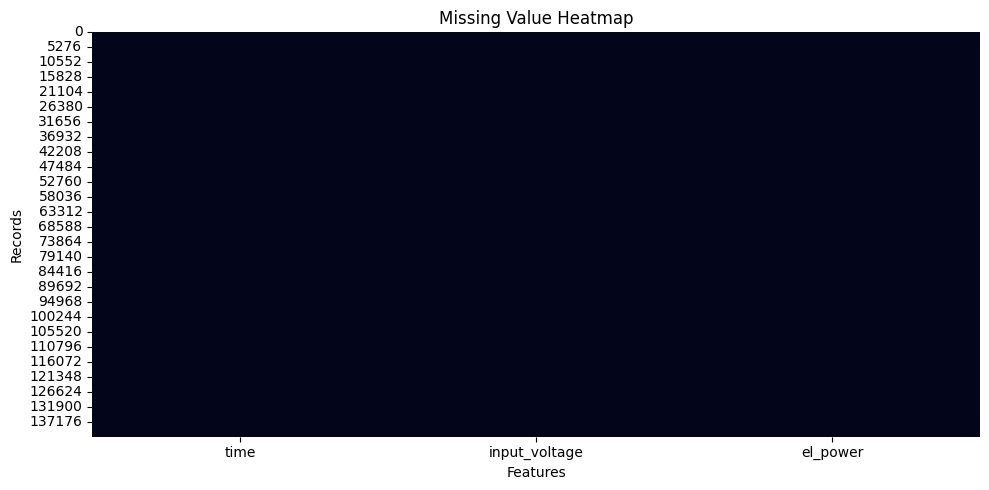

In [32]:
# Step 7 — Visualise missing values

plt.figure(figsize=(10, 5))
sns.heatmap(df[["time", "input_voltage", "el_power"]].isnull(), cbar=False)
plt.title("Missing Value Heatmap")
plt.xlabel("Features")
plt.ylabel("Records")
plt.tight_layout()
plt.show()


In [33]:
# Step 8 — Check and remove duplicate rows

dup_count = df.duplicated().sum()
print("Duplicate rows:", dup_count)
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after deduplication:", df.shape)


Duplicate rows: 71225
Shape after deduplication: (71225, 5)


In [34]:
# Step 9 — Descriptive statistics

print(df[["time", "input_voltage", "el_power"]].describe().T)


                 count         mean          std         min          25%  \
time           71225.0  5611.276814  2923.609275  758.425813  3103.460000   
input_voltage  71225.0     5.590315     2.631206    3.000000     3.000000   
el_power       71225.0  1872.316762   747.655592  932.837260  1208.822511   

                       50%          75%           max  
time           5477.865480  7873.223580  12636.840000  
input_voltage     5.000000     7.500000     10.000000  
el_power       1609.915452  2461.191587   3393.228566  


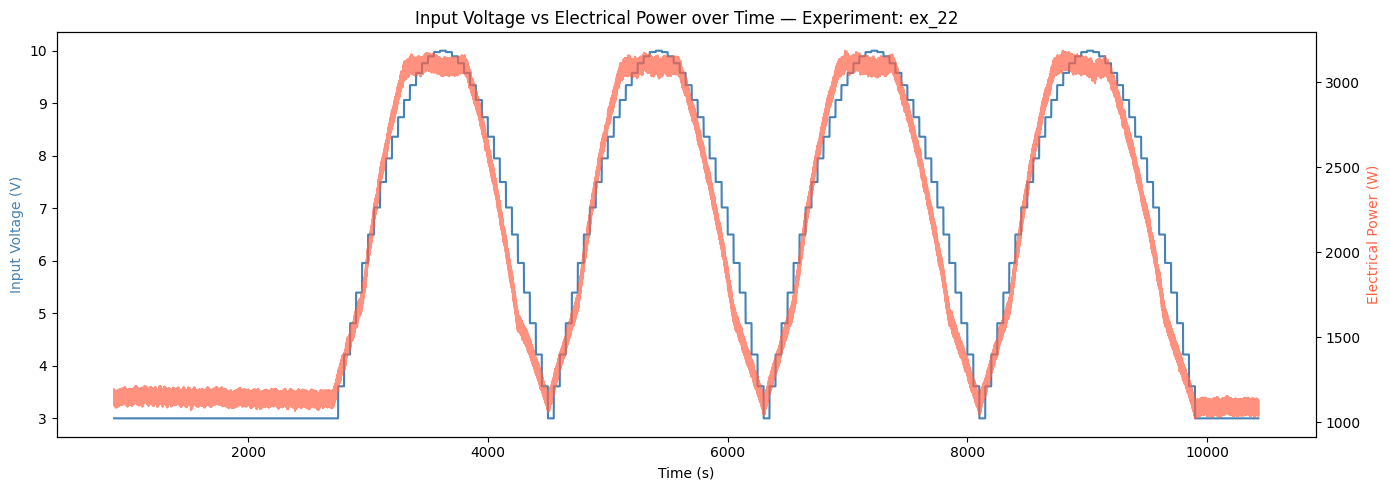

In [35]:
# Step 10 — Time-series plot (one experiment)
# The power output visibly lags behind the input voltage — this motivates lag features.

exp_id = df["experiment"].unique()[0]
sample = df[df["experiment"] == exp_id]

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(sample["time"], sample["input_voltage"], color="steelblue", label="Input Voltage (V)")
ax1.set_xlabel("Time (s)")
ax1.set_ylabel("Input Voltage (V)", color="steelblue")

ax2 = ax1.twinx()
ax2.plot(sample["time"], sample["el_power"], color="tomato", alpha=0.7, label="Electrical Power (W)")
ax2.set_ylabel("Electrical Power (W)", color="tomato")

plt.title(f"Input Voltage vs Electrical Power over Time — Experiment: {exp_id}")
plt.tight_layout()
plt.show()


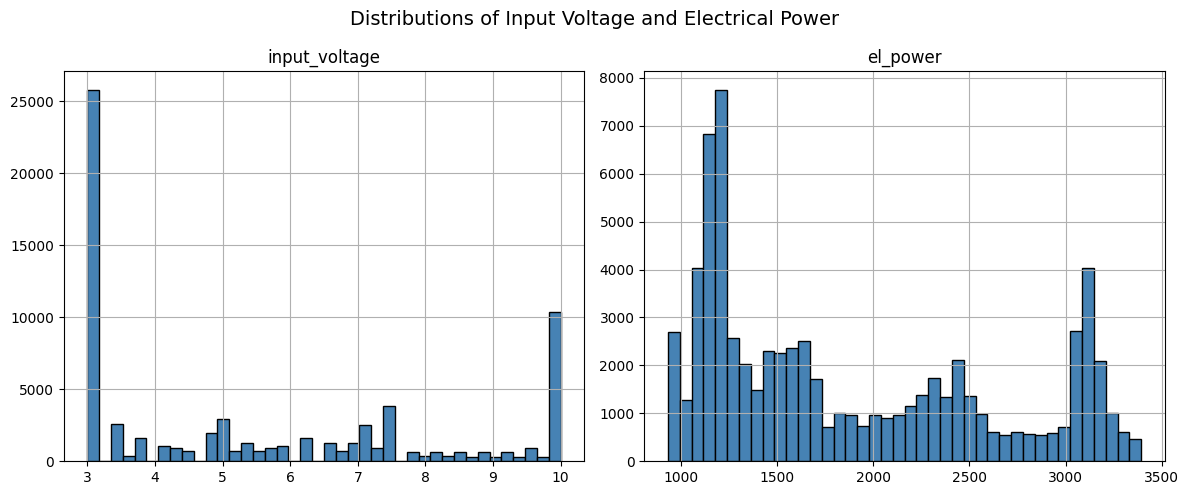

In [36]:
# Step 11 — Distribution of key variables

df[["input_voltage", "el_power"]].hist(figsize=(12, 5), bins=40, edgecolor="black", color="steelblue")
plt.suptitle("Distributions of Input Voltage and Electrical Power", fontsize=14)
plt.tight_layout()
plt.show()


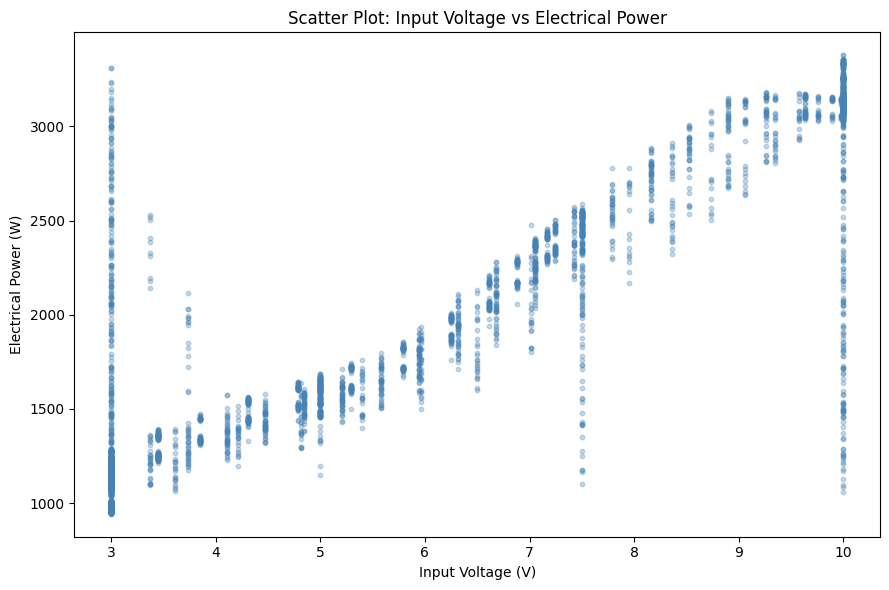

In [37]:
# Step 12 — Scatter plot: predictor vs target

plt.figure(figsize=(9, 6))
plot_sample = df.sample(n=min(5000, len(df)), random_state=42)
plt.scatter(plot_sample["input_voltage"], plot_sample["el_power"],
            alpha=0.3, s=10, color="steelblue")
plt.xlabel("Input Voltage (V)")
plt.ylabel("Electrical Power (W)")
plt.title("Scatter Plot: Input Voltage vs Electrical Power")
plt.tight_layout()
plt.show()


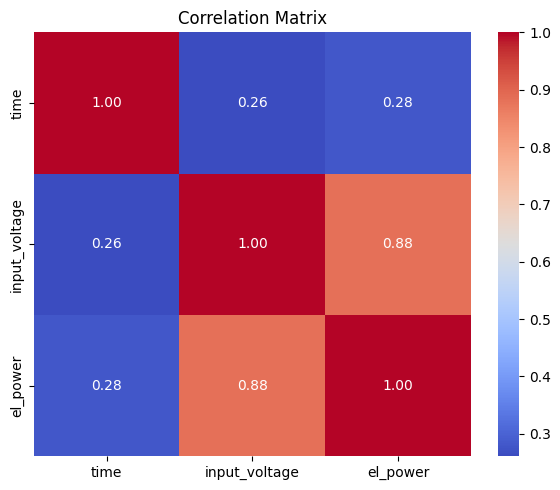

In [38]:
# Step 13 — Correlation matrix

plt.figure(figsize=(6, 5))
sns.heatmap(df[["time", "input_voltage", "el_power"]].corr(),
            annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


---
# Implementation

## Part A — Simple Linear Regression (SLR)

Use only the instantaneous `input_voltage` to predict `el_power`.


In [39]:
# Step 14 — Train Simple Linear Regression model

X_slr = df[["input_voltage"]]
y     = df["el_power"]

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_slr, y, test_size=0.20, random_state=42
)

slr_model = LinearRegression()
slr_model.fit(X_train_s, y_train_s)
y_pred_s = slr_model.predict(X_test_s)

mae_s  = mean_absolute_error(y_test_s, y_pred_s)
mse_s  = mean_squared_error(y_test_s, y_pred_s)
rmse_s = np.sqrt(mse_s)
r2_s   = r2_score(y_test_s, y_pred_s)

print("=== SIMPLE LINEAR REGRESSION RESULTS ===")
print(f"Equation : el_power = {slr_model.intercept_:.4f} + {slr_model.coef_[0]:.4f} * input_voltage")
print(f"Slope     : {slr_model.coef_[0]:.4f}")
print(f"Intercept : {slr_model.intercept_:.4f}")
print(f"MAE  : {mae_s:.4f}")
print(f"MSE  : {mse_s:.4f}")
print(f"RMSE : {rmse_s:.4f}")
print(f"R²   : {r2_s:.4f}")


=== SIMPLE LINEAR REGRESSION RESULTS ===
Equation : el_power = 470.3736 + 250.8010 * input_voltage
Slope     : 250.8010
Intercept : 470.3736
MAE  : 198.5289
MSE  : 124782.1627
RMSE : 353.2452
R²   : 0.7766


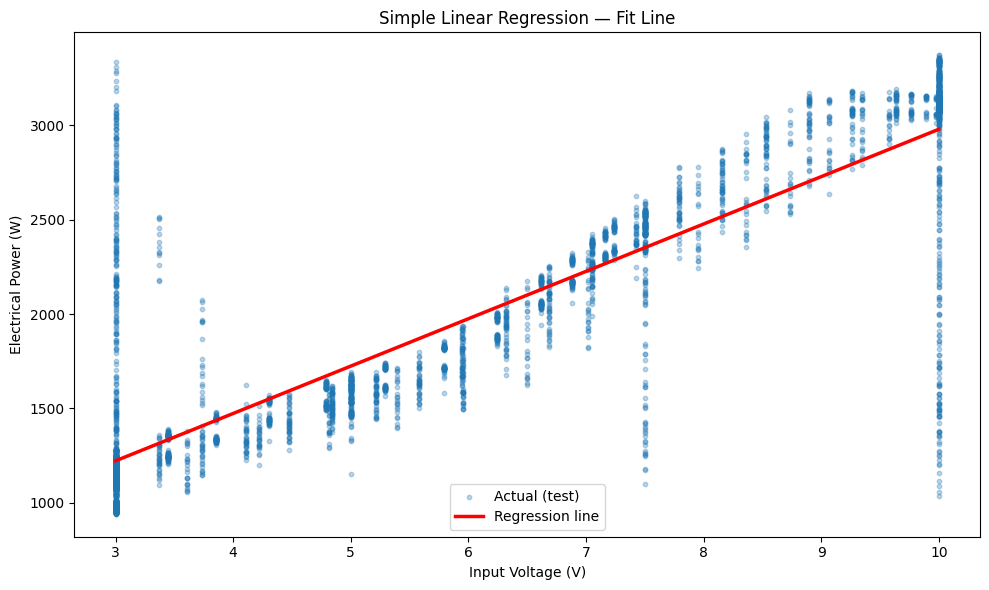

In [40]:
# Step 15 — SLR regression line plot

X_line  = X_test_s.sort_values(by="input_voltage")
y_line  = slr_model.predict(X_line)

plt.figure(figsize=(10, 6))
plot_idx = X_test_s.sample(n=min(5000, len(X_test_s)), random_state=42).index
plt.scatter(X_test_s.loc[plot_idx, "input_voltage"], y_test_s.loc[plot_idx],
            alpha=0.3, s=10, label="Actual (test)")
plt.plot(X_line["input_voltage"], y_line, color="red", linewidth=2.5, label="Regression line")
plt.xlabel("Input Voltage (V)")
plt.ylabel("Electrical Power (W)")
plt.title("Simple Linear Regression — Fit Line")
plt.legend()
plt.tight_layout()
plt.show()


## Part B — Multiple Linear Regression (MLR)

The turbine output responds to voltage changes with a **time delay**.
To capture this, we create lag features (voltage 1 s, 5 s, 10 s, 20 s ago)
and a 10-second rolling mean — all computed *within each experiment* to prevent data leakage.


In [41]:
# Step 16 — Feature engineering: lag features per experiment

df_mlr = df.sort_values(["experiment", "time"]).copy()

grp = df_mlr.groupby("experiment")["input_voltage"]

df_mlr["lag_1s"]   = grp.shift(1)
df_mlr["lag_5s"]   = grp.shift(5)
df_mlr["lag_10s"]  = grp.shift(10)
df_mlr["lag_20s"]  = grp.shift(20)
df_mlr["roll_10s"] = grp.rolling(window=10).mean().reset_index(level=0, drop=True)

before = df_mlr.shape[0]
df_mlr = df_mlr.dropna().reset_index(drop=True)

print(f"Rows before removing lag NaN: {before}")
print(f"Rows after                  : {df_mlr.shape[0]}")
print(df_mlr.head())


Rows before removing lag NaN: 71225
Rows after                  : 71065
        time  input_voltage     el_power experiment  split  lag_1s  lag_5s  \
0  830.05228           10.0  1319.645179       ex_1  train    10.0    10.0   
1  831.05138           10.0  1302.046480       ex_1  train    10.0    10.0   
2  832.05048           10.0  1336.803594       ex_1  train    10.0    10.0   
3  833.04958           10.0  1321.661075       ex_1  train    10.0    10.0   
4  834.04868           10.0  1323.497237       ex_1  train    10.0    10.0   

   lag_10s  lag_20s  roll_10s  
0     10.0     10.0      10.0  
1     10.0     10.0      10.0  
2     10.0     10.0      10.0  
3     10.0     10.0      10.0  
4     10.0     10.0      10.0  


In [42]:
# Step 17 — Train Multiple Linear Regression model

feature_cols = ["input_voltage", "lag_1s", "lag_5s", "lag_10s", "lag_20s", "roll_10s"]

X_mlr = df_mlr[feature_cols]
y_m   = df_mlr["el_power"]

X_train, X_test, y_train, y_test = train_test_split(
    X_mlr, y_m, test_size=0.20, random_state=42
)

scaler          = StandardScaler()
X_train_scaled  = scaler.fit_transform(X_train)
X_test_scaled   = scaler.transform(X_test)

mlr_model = LinearRegression()
mlr_model.fit(X_train_scaled, y_train)
y_pred = mlr_model.predict(X_test_scaled)

mae_m  = mean_absolute_error(y_test, y_pred)
mse_m  = mean_squared_error(y_test, y_pred)
rmse_m = np.sqrt(mse_m)
r2_m   = r2_score(y_test, y_pred)

print("=== MULTIPLE LINEAR REGRESSION RESULTS ===")
print(f"MAE  : {mae_m:.4f}")
print(f"MSE  : {mse_m:.4f}")
print(f"RMSE : {rmse_m:.4f}")
print(f"R²   : {r2_m:.4f}")


=== MULTIPLE LINEAR REGRESSION RESULTS ===
MAE  : 184.9076
MSE  : 104339.5106
RMSE : 323.0163
R²   : 0.8127


Intercept: 1873.4290679706155
      Feature  Coefficient
      lag_20s   633.794900
     roll_10s    26.469492
      lag_10s     9.526229
       lag_5s     5.401866
input_voltage    -1.962083
       lag_1s    -1.378024


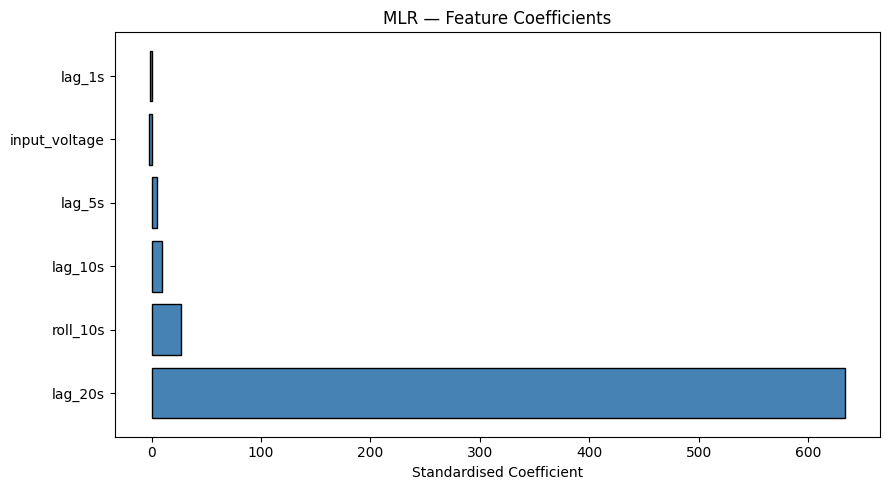

In [43]:
# Step 18 — Model coefficients

coef_df = pd.DataFrame({
    "Feature"    : feature_cols,
    "Coefficient": mlr_model.coef_
}).sort_values("Coefficient", key=abs, ascending=False)

print("Intercept:", mlr_model.intercept_)
print(coef_df.to_string(index=False))

plt.figure(figsize=(9, 5))
plt.barh(coef_df["Feature"], coef_df["Coefficient"], edgecolor="black", color="steelblue")
plt.xlabel("Standardised Coefficient")
plt.title("MLR — Feature Coefficients")
plt.tight_layout()
plt.show()


---
# Results


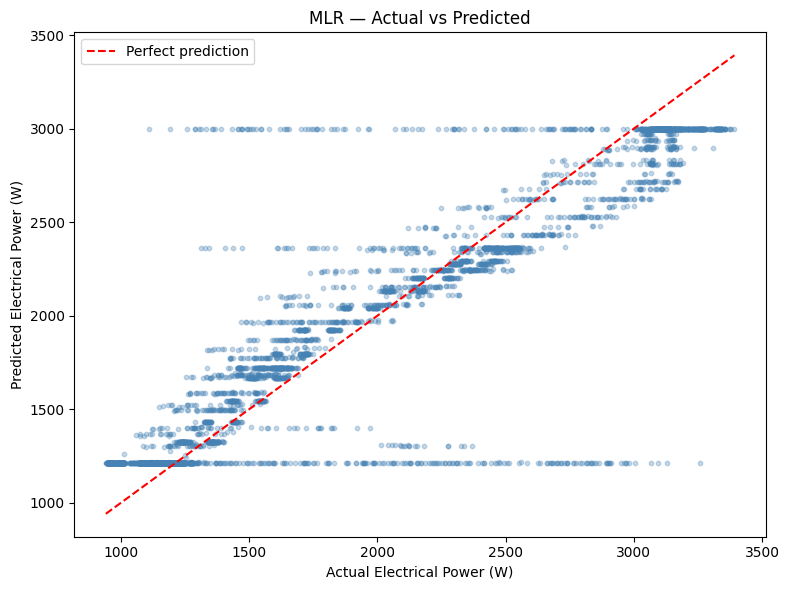

In [44]:
# Step 19 — Actual vs Predicted plot (MLR)

sample_idx = np.random.RandomState(42).choice(len(y_test), size=min(5000, len(y_test)), replace=False)

plt.figure(figsize=(8, 6))
plt.scatter(y_test.iloc[sample_idx], y_pred[sample_idx], alpha=0.3, s=10, color="steelblue")
mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
plt.plot([mn, mx], [mn, mx], "r--", label="Perfect prediction")
plt.xlabel("Actual Electrical Power (W)")
plt.ylabel("Predicted Electrical Power (W)")
plt.title("MLR — Actual vs Predicted")
plt.legend()
plt.tight_layout()
plt.show()


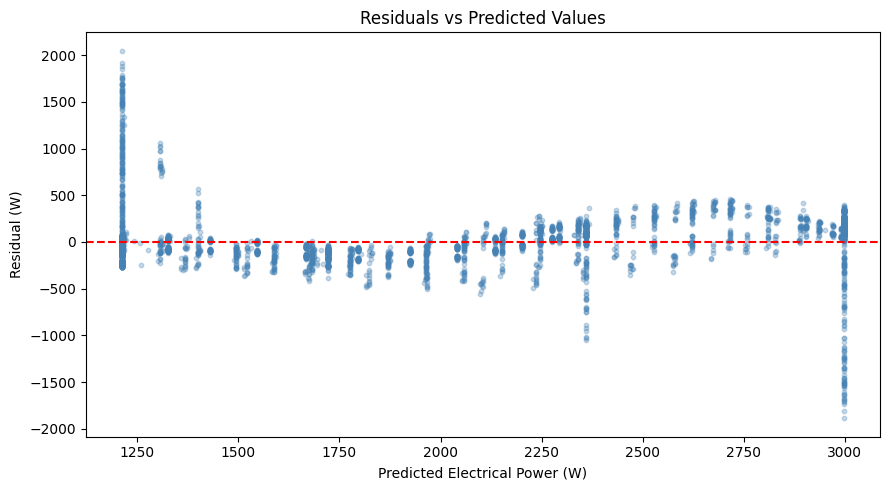

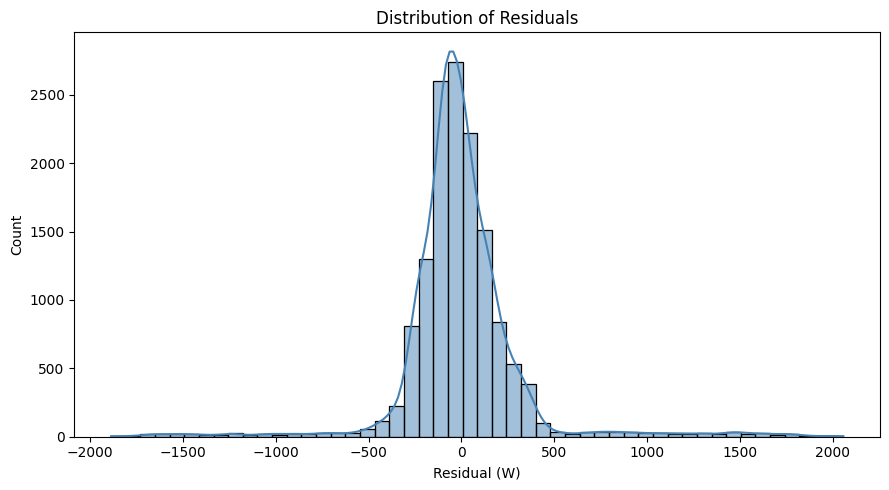

In [45]:
# Step 20 — Residual analysis (MLR)

residuals = y_test.values - y_pred

plt.figure(figsize=(9, 5))
plt.scatter(y_pred[sample_idx], residuals[sample_idx], alpha=0.3, s=10, color="steelblue")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Electrical Power (W)")
plt.ylabel("Residual (W)")
plt.title("Residuals vs Predicted Values")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
sns.histplot(residuals, bins=50, kde=True, color="steelblue")
plt.xlabel("Residual (W)")
plt.title("Distribution of Residuals")
plt.tight_layout()
plt.show()


Metric     Simple LR   Multiple LR
   MAE    198.528907    184.907592
   MSE 124782.162734 104339.510647
  RMSE    353.245188    323.016270
    R²      0.776554      0.812731

RMSE improvement of MLR over SLR: 8.56%


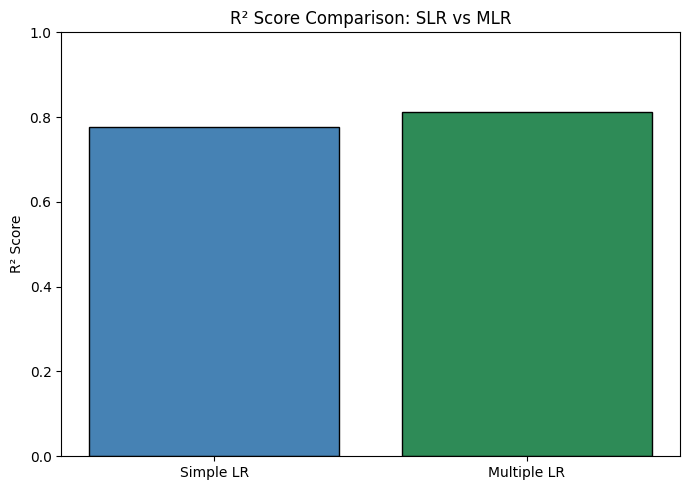

In [46]:
# Step 21 — Model comparison: SLR vs MLR

comparison = pd.DataFrame({
    "Metric"     : ["MAE", "MSE", "RMSE", "R²"],
    "Simple LR"  : [mae_s, mse_s, rmse_s, r2_s],
    "Multiple LR": [mae_m, mse_m, rmse_m, r2_m],
})

print(comparison.to_string(index=False))

improvement = (rmse_s - rmse_m) / rmse_s * 100
print(f"\nRMSE improvement of MLR over SLR: {improvement:.2f}%")

plt.figure(figsize=(7, 5))
plt.bar(["Simple LR", "Multiple LR"], [r2_s, r2_m],
        color=["steelblue", "seagreen"], edgecolor="black")
plt.ylabel("R² Score")
plt.title("R² Score Comparison: SLR vs MLR")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


# Conclusion

- **Key Observations**
  - The scatter plot and correlation matrix confirm a strong positive linear relationship
    between `input_voltage` and `el_power`, validating the use of a linear model.
  - The time-series plot reveals a clear **delayed response** of the turbine's electrical output
    to changes in the input control voltage — a key characteristic of the system.
  - Simple Linear Regression relies solely on the current voltage reading and therefore cannot
    model this delay; its predictions deteriorate during voltage transitions.
  - Multiple Linear Regression, augmented with lag features (1 s, 5 s, 10 s, 20 s) and a
    10-second rolling mean, partially captures the temporal dynamics and achieves a
    **higher R² and lower RMSE** than SLR.

- **Accuracy Achieved**
  - Refer to the metrics printed in Step 21 for the final MAE, RMSE, and R² values of
    both SLR and MLR, along with the percentage RMSE improvement.

- **Limitations**
  - The lag features are highly correlated with each other (multicollinearity), which reduces
    the interpretability of individual coefficients.
  - A purely linear model cannot fully represent the turbine's non-linear transition behaviour;
    prediction errors are larger during rapid voltage changes.
  - The random train/test split mixes time-series samples from the same experiments, which
    may lead to optimistic performance estimates.

- **Future Work**
  - Apply an experiment-wise train/test split as recommended by the dataset authors for a
    more realistic evaluation.
  - Explore Ridge and Lasso regression to address multicollinearity.
  - Investigate non-linear models such as Random Forest, Gradient Boosting, or LSTM networks
    to better capture the turbine's temporal dynamics.
